In [32]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import joblib
import os
import re as re
import json
import zipfile

In [ ]:
# Load feature_df_raw
# Load feature_df_raw and feature_df_enc
with zipfile.ZipFile(f"../csv_outputs/feature_df_raw.zip") as zf:
    with zf.open("feature_df_raw.csv") as f:
        feature_df_raw = pd.read_csv(f, index_col=0)
with zipfile.ZipFile(f"../csv_outputs/feature_df_enc.zip") as zf:
    with zf.open("feature_df_enc.csv") as f:
        feature_df_enc = pd.read_csv(f, index_col=0)

# **1. Model training, validation & testing**

* Temporal train/validation/test split: 
  * Train on older data (<=2022) 
  * Validate on newer data (2023)
  * Test on newer data (>=2024)

* Train and compare models based on the following loss functions: 
  * Lin-Lin/Pinball loss (asymmetric) with alpha=0.75
    * Penalise under-predictions more heavily (alpha>0.5) due to budget constraint
  * MSE (symmetric)

* Models:
  * Random Forest (trained on MSE only, Lin-Lin loss is not supported)
  * LightGBM (trained on Lin-Lin and MSE)
  * XGBoost (trained on Lin-Lin and MSE)
  * CatBoost (trained on Lin-Lin and MSE)
  * Ensemble - combined forecasts 
    * Simple average (equal weights)
    * Optimised weights 

* Hyperparameter tuning: done using Optuna library

* Choosing the final prediction model: Diebold-Mariano (DM) Test
  * Compare symmetric vs asymmetric individual models (LightGBM, XGBoost, CatBoost)
  * Using the winning loss function, compare ensemble of models trained on that loss function vs the best-performing individual model
  * If ensemble wins, compare ensemble with vs without adding Random Forest (ie. test if adding a model trained on symmetric loss can balance the predictions of the models trained on asymmetric loss)
  * Using the winning ensemble combination, compare equal vs optimised weights 

**1a. Train/validation/test split**

In [5]:
TARGET = "real_price"
FEATURES = [c for c in feature_df_raw.columns if c not in (TARGET, "rpi")]

split_index = (2024 - 2017) * 12 # 84: test boundary (Jan 2024)
val_split = split_index - 12 # 72: last 12 months of train used as validation

# Use raw (non-encoded) training data for XGBoost, CatBoost, LightGBM and baseline median models
train_df = feature_df_raw[feature_df_raw["month_index"] < val_split]
val_df = feature_df_raw[(feature_df_raw["month_index"] >= val_split) &
                           (feature_df_raw["month_index"] < split_index)]
test_df = feature_df_raw[feature_df_raw["month_index"] >= split_index]
X_train_raw, X_val_raw, X_test_raw = train_df[FEATURES], val_df[FEATURES], test_df[FEATURES]
y_train, y_val, y_test = train_df[TARGET], val_df[TARGET], test_df[TARGET]

# CatBoost needs column indices for categorical features
cat_cols = ["town", "flat_type"]
cat_idx = [X_train_raw.columns.get_loc(c) for c in cat_cols]

# Split RPI arrays for conversion to nominal values
rpi_train, rpi_val, rpi_test = train_df["rpi"].values, val_df["rpi"].values, test_df["rpi"].values

RPI_BASE = 100.0
print(f"RPI range in data: {feature_df_raw["rpi"].min():.1f} – {feature_df_raw["rpi"].max():.1f}")

# Use encoded training data for Random Forest (cannot handle string categoricals natively)
train_df_enc = feature_df_enc[feature_df_enc["month_index"] < val_split]
val_df_enc = feature_df_enc[(feature_df_enc["month_index"] >= val_split) &
                               (feature_df_enc["month_index"] < split_index)]
test_df_enc = feature_df_enc[feature_df_enc["month_index"] >= split_index]
X_train_enc, X_val_enc, X_test_enc = train_df_enc[FEATURES], val_df_enc[FEATURES], test_df_enc[FEATURES]

print(f"Train: {len(X_train_enc):,} | Val: {len(X_val_enc):,} | Test: {len(X_test_enc):,}")

# Combine training + validation set to refit the final model after hyperparameter tuning
X_trainval_raw = pd.concat([X_train_raw, X_val_raw]).reset_index(drop=True)
X_trainval = pd.concat([X_train_enc, X_val_enc]).reset_index(drop=True)
y_trainval = pd.concat([y_train, y_val]).reset_index(drop=True)

for col in cat_cols:
    X_train_raw[col] = X_train_raw[col].astype("category")
    X_val_raw[col] = X_val_raw[col].astype("category")
    X_test_raw[col] = X_test_raw[col].astype("category")
    X_trainval_raw[col] = X_trainval_raw[col].astype("category")

RPI range in data: 130.8 – 203.7
Train: 143,396 | Val: 25,754 | Test: 58,976


**1b. Loss function & Alpha selection**

The asymmetric Lin-Lin (pinball) loss penalises under- and over-predictions differently:

$$L(e,\alpha) = \alpha \cdot e \text{ if } e \geq 0 \quad\text{(under-prediction)} \qquad (1-\alpha) \cdot |e| \text{ if } e < 0 \quad\text{(over-prediction)}$$

where $\alpha = c_{\text{under}} / (c_{\text{under}} + c_{\text{over}})$ and $e = y_{\text{true}} - \hat{y}$.

**Choosing $\alpha$ in the HDB buyer context:**
- **Under-prediction** ($\hat{y} < \text{actual}$): buyer's budget may be insufficient: more costly
- **Over-prediction** ($\hat{y} > \text{actual}$): buyer has surplus budget: less costly, but wastes search effort

As the relative severity of over- vs under-prediction in this context is subjective and there are no defined cost functions, we apply the following assumptions in deciding our value of $\alpha$:

* Symmetric loss: under-prediction is equally as costly as over-prediction
* Asymmetric loss: under-prediction is 3x as costly as over-prediction, since buyers would not want to exceed their budget. 

Followig these assumptions, we select the following values of $\alpha$:

| Assumption | Cost ratio $c_u : c_o$ | $\alpha$ |
|---|---|---|
| Symmetric baseline | 1 : 1 | 0.5 |
| Asymmetric | 3 : 1 | 0.75 |

These values are validated (but not determined) by checking that empirical coverage $\approx$ 0.5 and 0.75 respectively on the validation set.

In [6]:
ALPHA_SYM = 0.5 # symmetric baseline: equal costs (c_under = c_over)
ALPHA_ASYM = 0.75 # asymmetric: c_under = 3 × c_over
ALPHA = ALPHA_ASYM

def linlin_loss(y_true, y_pred, alpha=ALPHA):
    errors = y_true - y_pred
    loss = np.where(errors >= 0, alpha * errors, (1 - alpha) * (-errors))
    return loss, loss.mean()

**1c. Model training & hyperparameter tuning**

In [12]:
def to_nominal(real_pred, rpi_series, rpi_base=RPI_BASE):
    return np.array(real_pred) * (np.array(rpi_series) / rpi_base)

def evaluate(name, y_true, y_pred, rpi_series, alpha=ALPHA):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    errors = y_true - y_pred
    linlin = np.mean(np.where(errors >= 0, alpha * errors, (alpha - 1) * errors))
    cov = np.mean(y_true <= y_pred)
    nominal_mae = mean_absolute_error(
        to_nominal(y_true, rpi_series),
        to_nominal(y_pred, rpi_series)
    )
    print(f"\n{name} (alpha={alpha})")
    print(f"Lin-Lin: {linlin:,.0f}")
    print(f"Coverage: {cov:.3f}")
    print(f"MAE (nominal $): ${nominal_mae:,.0f}")
    print(f"RMSE (real $): ${rmse:,.0f}")
    print(f"MAPE: {mape:.2f}%")
    return {"name": name, "Lin-Lin": linlin, "Coverage": cov,
            "MAE_nominal": nominal_mae, "MAE": mae, "RMSE": rmse, "MAPE": mape}

In [8]:
# Benchmarks
## Global Median
overall_train_median = train_df[TARGET].median()
global_median_pred = np.full(len(y_test), overall_train_median)
res_global_median = evaluate("Global Median", y_test, global_median_pred, rpi_test)

## Stratified Median (town x flat_type)
group_median_map = (
    train_df.groupby(["town", "flat_type"])[TARGET]
    .median().rename("group_median")
)
stratified_median = (
    test_df[["town", "flat_type"]]
    .join(group_median_map, on=["town", "flat_type"])
    ["group_median"].fillna(overall_train_median).values
)
res_strat_median = evaluate("Stratified Median (town x flat_type)", y_test, stratified_median, rpi_test)


Global Median (alpha=0.75)
Lin-Lin: 40,121
Coverage: 0.525 (target ≈ 0.75)
MAE (nominal $): $151,043
RMSE (real $): $100,229
MAPE: 25.50%

Stratified Median (town x flat_type) (alpha=0.75)
Lin-Lin: 20,399
Coverage: 0.505 (target ≈ 0.75)
MAE (nominal $): $76,582
RMSE (real $): $56,456
MAPE: 11.84%


In [9]:
# Linear Regression (Ridge): symmetric baseline
# No quantile variant exists. Evaluated on both symmetric and asymmetric metrics.
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train_enc)
X_val_sc = scaler.transform(X_val_enc)
X_tv_sc = scaler.transform(X_trainval) # train+val encoded
X_te_sc = scaler.transform(X_test_enc)

lr_model = Ridge(alpha=1.0)
lr_model.fit(X_tv_sc, y_trainval)
lr_val_pred = lr_model.predict(X_val_sc)
lr_pred = lr_model.predict(X_te_sc)

res_lr = evaluate("Linear Regression (Ridge)", y_test, lr_pred, rpi_test)


Linear Regression (Ridge) (alpha=0.75)
Lin-Lin: 16,477
Coverage: 0.520 (target ≈ 0.75)
MAE (nominal $): $64,649
RMSE (real $): $42,506
MAPE: 11.04%


In [ ]:
# Random Forest: Symmetric loss only 
# RF cannot use quantile/LinLin loss natively
optuna.logging.set_verbosity(optuna.logging.WARNING)

def rf_objective(trial):
    model = RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 3, 15),
        max_features=trial.suggest_float("max_features", 0.3, 0.8),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        n_jobs=-1, random_state=42
    )
    model.fit(X_train_enc, y_train)
    return mean_absolute_error(y_val, model.predict(X_val_enc)) # tune on MAE

rf_study = optuna.create_study(direction="minimize",
                               sampler=optuna.samplers.TPESampler(seed=42, multivariate=True))
rf_study.optimize(rf_objective, n_trials=20, show_progress_bar=True)
print("Best RF params:", rf_study.best_params)

rf_model_val = RandomForestRegressor(n_estimators=400, **rf_study.best_params,
                                     n_jobs=-1, random_state=42)
rf_model_val.fit(X_train_enc, y_train)
rf_val_pred = rf_model_val.predict(X_val_enc)

rf_model = RandomForestRegressor(n_estimators=400, **rf_study.best_params,
                                 n_jobs=-1, random_state=42)
rf_model.fit(X_trainval, y_trainval)
rf_pred = rf_model.predict(X_test_enc)

res_rf = evaluate("Random Forest (Symmetric)", y_test, rf_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 7. Best value: 15591.7: 100%|██████████| 20/20 [11:12<00:00, 33.63s/it]


Best RF params: {'min_samples_leaf': 6, 'max_features': 0.44607232426760907, 'max_depth': 20}

Random Forest (Symmetric) (alpha=0.75)
Lin-Lin: 7,064
Coverage: 0.565 (target ≈ 0.75)
MAE (nominal $): $30,989
RMSE (real $): $22,361
MAPE: 4.85%


In [11]:
# LightGBM: Asymmetric variant 
def lgb_safe(df):
    df = df.copy()
    df.columns = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in df.columns]
    return df

X_train_lgb = lgb_safe(X_train_raw)
X_val_lgb = lgb_safe(X_val_raw)
X_test_lgb = lgb_safe(X_test_raw)
X_trainval_lgb = lgb_safe(X_trainval_raw)
cat_cols_lgb = [re.sub(r"[^A-Za-z0-9_]", "_", c) for c in cat_cols]

optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_objective(trial):
    model = lgb.LGBMRegressor(
        n_estimators=3000,
        objective="quantile", alpha=ALPHA_ASYM,
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 20, 150),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 100),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1
    )
    model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
              categorical_feature=cat_cols_lgb,
              callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    _, pl = linlin_loss(y_val.values, model.predict(X_val_lgb), ALPHA_ASYM)
    return pl

lgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
lgb_study.optimize(lgb_objective, n_trials=20, show_progress_bar=True)
print("Best LGB params:", lgb_study.best_params)

lgb_model_val = lgb.LGBMRegressor(
    n_estimators=3000, objective="quantile", alpha=ALPHA_ASYM,
    **lgb_study.best_params, random_state=42, n_jobs=-1
)
lgb_model_val.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
                  categorical_feature=cat_cols_lgb,
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(50)])
lgb_val_pred = lgb_model_val.predict(X_val_lgb)
best_lgb_iter = lgb_model_val.best_iteration_
print(f"Best LightGBM iteration: {best_lgb_iter}")

lgb_model = lgb.LGBMRegressor(
    n_estimators=best_lgb_iter, objective="quantile", alpha=ALPHA_ASYM,
    **lgb_study.best_params, random_state=42, n_jobs=-1
)
lgb_model.fit(X_trainval_lgb, y_trainval, categorical_feature=cat_cols_lgb,
              callbacks=[lgb.log_evaluation(50)])
lgb_pred = lgb_model.predict(X_test_lgb)

res_lgb = evaluate("LightGBM (Asymmetric)", y_test, lgb_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
  0%|          | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008835 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[769]	valid_0's quantile: 5967.5


Best trial: 0. Best value: 5967.5:   5%|▌         | 1/20 [00:13<04:14, 13.37s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.031131 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[679]	valid_0's quantile: 6070.4


Best trial: 0. Best value: 5967.5:  10%|█         | 2/20 [00:30<04:45, 15.87s/it]

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011612 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1466]	valid_0's quantile: 5963.69


Best trial: 10. Best value: 5921.55:  95%|█████████▌| 19/20 [11:15<00:33, 33.90s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012800 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2173]	valid_0's quantile: 5998.26


Best trial: 10. Best value: 5921.55: 100%|██████████| 20/20 [11:44<00:00, 35.22s/it]


Best LGB params: {'learning_rate': 0.034907905414608316, 'num_leaves': 138, 'min_child_samples': 87, 'subsample': 0.8737239523738184, 'colsample_bytree': 0.5347932177377854, 'reg_lambda': 0.8392491702129204, 'reg_alpha': 0.00010850871665981005}
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 392670.156250
Training until validation scores don't improve for 100 rounds
[50]	valid_0's quantile: 11028.3
[100]	valid_0's quantile: 7405.76
[150]	valid_0's quantile: 6565.37
[200]	valid_0's quantile: 6304.96
[250]	valid_0's quantile: 6202.14
[300]	valid_0's quantile: 6132.7
[350]	valid_0's quantile: 6094.16
[400]	valid_0's quantile: 6066.28
[450]	valid

In [13]:
# LightGBM: Symmetric variant
optuna.logging.set_verbosity(optuna.logging.WARNING)

def lgb_sym_objective(trial):
    model = lgb.LGBMRegressor(
        n_estimators=3000,
        objective="regression",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        num_leaves=trial.suggest_int("num_leaves", 20, 150),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 100),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1
    )
    model.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
              categorical_feature=cat_cols_lgb,
              callbacks=[lgb.early_stopping(100), lgb.log_evaluation(0)])
    return mean_absolute_error(y_val, model.predict(X_val_lgb))

lgb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
lgb_sym_study.optimize(lgb_sym_objective, n_trials=20, show_progress_bar=True)
print("Best LGB sym params:", lgb_sym_study.best_params)

lgb_sym_model_val = lgb.LGBMRegressor(
    n_estimators=3000, objective="regression",
    **lgb_sym_study.best_params, random_state=42, n_jobs=-1
)
lgb_sym_model_val.fit(X_train_lgb, y_train, eval_set=[(X_val_lgb, y_val)],
                      categorical_feature=cat_cols_lgb,
                      callbacks=[lgb.early_stopping(100), lgb.log_evaluation(50)])
lgb_sym_val_pred = lgb_sym_model_val.predict(X_val_lgb)
best_lgb_sym_iter = lgb_sym_model_val.best_iteration_

lgb_sym_model = lgb.LGBMRegressor(
    n_estimators=best_lgb_sym_iter, objective="regression",
    **lgb_sym_study.best_params, random_state=42, n_jobs=-1
)
lgb_sym_model.fit(X_trainval_lgb, y_trainval, categorical_feature=cat_cols_lgb,
                  callbacks=[lgb.log_evaluation(50)])
lgb_sym_pred = lgb_sym_model.predict(X_test_lgb)

res_lgb_sym = evaluate("LightGBM (Symmetric)", y_test, lgb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
  0%|          | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008529 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[514]	valid_0's l2: 4.46845e+08


Best trial: 0. Best value: 14988.4:   5%|▌         | 1/20 [00:06<02:05,  6.61s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[348]	valid_0's l2: 4.85778e+08


Best trial: 0. Best value: 14988.4:  10%|█         | 2/20 [00:16<02:33,  8.51s/it]

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[1077]	valid_0's l2: 4.65399e+08


Best trial: 0. Best value: 14988.4:  95%|█████████▌| 19/20 [06:03<00:27, 27.12s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[672]	valid_0's l2: 4.51566e+08


Best trial: 0. Best value: 14988.4: 100%|██████████| 20/20 [06:25<00:00, 19.28s/it]


Best LGB sym params: {'learning_rate': 0.054816785328198704, 'num_leaves': 144, 'min_child_samples': 76, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'reg_lambda': 0.8499489191350383, 'reg_alpha': 0.00018747059221802545}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021217 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6751
[LightGBM] [Info] Number of data points in the train set: 143396, number of used features: 35
[LightGBM] [Info] Start training from score 335309.553833
Training until validation scores don't improve for 100 rounds
[50]	valid_0's l2: 6.11193e+08
[100]	valid_0's l2: 5.05769e+08
[150]	valid_0's l2: 4.77255e+08
[200]	valid_0's l2: 4.66003e+08
[250]	valid_0's l2: 4.5749e+08
[300]	valid_0's l2: 4.53276e+08
[350]	valid_0's l2: 4.50782e+08
[400]	valid_0's l2: 4.48735e+08
[450]	valid_0's l2: 4.47906e+08
[500]	valid_0's l2: 4.47246e+08
[550]	valid_0's l2: 4.4

In [14]:
# XGBoost: Asymmetric
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_objective(trial):
    model = xgb.XGBRegressor(
        n_estimators=3000,
        objective="reg:quantileerror", quantile_alpha=ALPHA_ASYM,
        enable_categorical=True, tree_method="hist",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 8),
        min_child_weight=trial.suggest_int("min_child_weight", 5, 40),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1, early_stopping_rounds=100
    )
    model.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=False)
    _, pl = linlin_loss(y_val.values, model.predict(X_val_raw), ALPHA_ASYM)
    return pl

xgb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
xgb_study.optimize(xgb_objective, n_trials=20, show_progress_bar=True)

xgb_model_val = xgb.XGBRegressor(
    n_estimators=3000, objective="reg:quantileerror", quantile_alpha=ALPHA_ASYM,
    enable_categorical=True, tree_method="hist",
    **xgb_study.best_params, random_state=42, n_jobs=-1, early_stopping_rounds=100)
xgb_model_val.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=50)
print(f"Best iteration: {xgb_model_val.best_iteration}")
xgb_val_pred = xgb_model_val.predict(X_val_raw)

best_xgb_params = {k: v for k, v in xgb_study.best_params.items()
                   if k != "early_stopping_rounds"}
xgb_model = xgb.XGBRegressor(
    n_estimators=xgb_model_val.best_iteration + 1,
    objective="reg:quantileerror", quantile_alpha=ALPHA_ASYM,
    enable_categorical=True, tree_method="hist",
    **best_xgb_params, random_state=42, n_jobs=-1)
xgb_model.fit(X_trainval_raw, y_trainval, verbose=50)
xgb_pred = xgb_model.predict(X_test_raw)

res_xgb = evaluate("XGBoost (Asymmetric)", y_test, xgb_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 6. Best value: 5924.69: 100%|██████████| 20/20 [39:08<00:00, 117.41s/it]


[0]	validation_0-quantile:32937.00699
[50]	validation_0-quantile:11549.94996
[100]	validation_0-quantile:7485.51366
[150]	validation_0-quantile:6538.66895
[200]	validation_0-quantile:6299.56410
[250]	validation_0-quantile:6206.93331
[300]	validation_0-quantile:6126.92114
[350]	validation_0-quantile:6083.22969
[400]	validation_0-quantile:6049.73915
[450]	validation_0-quantile:6025.18038
[500]	validation_0-quantile:6012.57383
[550]	validation_0-quantile:5996.16350
[600]	validation_0-quantile:5981.23763
[650]	validation_0-quantile:5971.20864
[700]	validation_0-quantile:5965.09212
[750]	validation_0-quantile:5960.46689
[800]	validation_0-quantile:5956.35570
[850]	validation_0-quantile:5953.41739
[900]	validation_0-quantile:5949.26781
[950]	validation_0-quantile:5947.37662
[1000]	validation_0-quantile:5943.90578
[1050]	validation_0-quantile:5940.02474
[1100]	validation_0-quantile:5938.36912
[1150]	validation_0-quantile:5934.84761
[1200]	validation_0-quantile:5930.89025
[1250]	validation_0-q

In [15]:
# XGBoost: Symmetric
optuna.logging.set_verbosity(optuna.logging.WARNING)

def xgb_sym_objective(trial):
    model = xgb.XGBRegressor(
        n_estimators=3000,
        objective="reg:squarederror",
        enable_categorical=True, tree_method="hist",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        max_depth=trial.suggest_int("max_depth", 4, 8),
        min_child_weight=trial.suggest_int("min_child_weight", 5, 40),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 0.5, 15.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 5.0, log=True),
        random_state=42, n_jobs=-1, early_stopping_rounds=100
    )
    model.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=False)
    return mean_absolute_error(y_val, model.predict(X_val_raw))

xgb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
xgb_sym_study.optimize(xgb_sym_objective, n_trials=20, show_progress_bar=True)

best_xgb_sym_params = {k: v for k, v in xgb_sym_study.best_params.items()
                       if k != "early_stopping_rounds"}

xgb_sym_model_val = xgb.XGBRegressor(
    n_estimators=3000, objective="reg:squarederror",
    enable_categorical=True, tree_method="hist",
    **best_xgb_sym_params, random_state=42, n_jobs=-1, early_stopping_rounds=100)
xgb_sym_model_val.fit(X_train_raw, y_train, eval_set=[(X_val_raw, y_val)], verbose=50)
xgb_sym_val_pred = xgb_sym_model_val.predict(X_val_raw)
best_xgb_sym_iter = xgb_sym_model_val.best_iteration

xgb_sym_model = xgb.XGBRegressor(
    n_estimators=best_xgb_sym_iter + 1, objective="reg:squarederror",
    enable_categorical=True, tree_method="hist",
    **best_xgb_sym_params, random_state=42, n_jobs=-1)
xgb_sym_model.fit(X_trainval_raw, y_trainval, verbose=50)
xgb_sym_pred = xgb_sym_model.predict(X_test_raw)

res_xgb_sym = evaluate("XGBoost (Symmetric)", y_test, xgb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(
Best trial: 10. Best value: 15021.4: 100%|██████████| 20/20 [12:17<00:00, 36.86s/it]


[0]	validation_0-rmse:95642.10603
[50]	validation_0-rmse:31686.78261
[100]	validation_0-rmse:23292.56275
[150]	validation_0-rmse:22295.40482
[200]	validation_0-rmse:22041.30520
[250]	validation_0-rmse:21728.53397
[300]	validation_0-rmse:21515.10529
[350]	validation_0-rmse:21442.08911
[400]	validation_0-rmse:21365.48999
[450]	validation_0-rmse:21308.31633
[500]	validation_0-rmse:21272.25833
[550]	validation_0-rmse:21230.79255
[600]	validation_0-rmse:21194.93175
[650]	validation_0-rmse:21189.57354
[700]	validation_0-rmse:21172.91215
[750]	validation_0-rmse:21166.00810
[800]	validation_0-rmse:21159.37848
[850]	validation_0-rmse:21152.22865
[900]	validation_0-rmse:21138.82548
[950]	validation_0-rmse:21140.81337
[994]	validation_0-rmse:21142.07494

XGBoost (Symmetric) (alpha=0.75)
Lin-Lin: 6,780
Coverage: 0.563
MAE (nominal $): $29,654
RMSE (real $): $21,313
MAPE: 4.63%


In [20]:
# CatBoost: Asymmetric
def cb_objective(trial):
    model = CatBoostRegressor(
        iterations=3000,
        loss_function=f"Quantile:alpha={ALPHA_ASYM}",
        eval_metric=f"Quantile:alpha={ALPHA_ASYM}",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.5),
        rsm=trial.suggest_float("rsm", 0.5, 1.0),
        random_seed=42, verbose=False, early_stopping_rounds=100
    )
    model.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
              cat_features=cat_idx, use_best_model=True)
    _, pl = linlin_loss(y_val.values, model.predict(X_val_raw), ALPHA_ASYM)
    return pl

cb_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
cb_study.optimize(cb_objective, n_trials=20, show_progress_bar=True)

cb_model_val = CatBoostRegressor(
    iterations=3000,
    loss_function=f"Quantile:alpha={ALPHA_ASYM}", eval_metric=f"Quantile:alpha={ALPHA_ASYM}",
    **cb_study.best_params, random_seed=42, verbose=200, early_stopping_rounds=100)
cb_model_val.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
                 cat_features=cat_idx, use_best_model=True)
cb_val_pred = cb_model_val.predict(X_val_raw)
best_cb_iter = cb_model_val.best_iteration_
print(f"Best CatBoost iteration: {best_cb_iter}")

cb_model = CatBoostRegressor(
    iterations=best_cb_iter + 1,
    loss_function=f"Quantile:alpha={ALPHA_ASYM}", eval_metric=f"Quantile:alpha={ALPHA_ASYM}",
    **cb_study.best_params, random_seed=42, verbose=200)
cb_model.fit(X_trainval_raw, y_trainval, cat_features=cat_idx)
cb_pred = cb_model.predict(X_test_raw)

res_cb = evaluate("CatBoost (Asymmetric)", y_test, cb_pred, rpi_test)

Best trial: 18. Best value: 5853.13: 100%|██████████| 20/20 [2:19:21<00:00, 418.08s/it] 


0:	learn: 38174.9309016	test: 32974.0531509	best: 32974.0531509 (0)	total: 173ms	remaining: 8m 39s
200:	learn: 8586.9623457	test: 7499.3049768	best: 7499.3049768 (200)	total: 35.8s	remaining: 8m 19s
400:	learn: 7506.7793491	test: 6803.0021986	best: 6803.0021986 (400)	total: 1m 14s	remaining: 8m 2s
600:	learn: 6954.4339893	test: 6402.1336472	best: 6402.1336472 (600)	total: 1m 52s	remaining: 7m 28s
800:	learn: 6641.7696186	test: 6192.0337313	best: 6192.0337313 (800)	total: 2m 31s	remaining: 6m 56s
1000:	learn: 6438.8890636	test: 6071.6975231	best: 6071.6975231 (1000)	total: 3m 13s	remaining: 6m 27s
1200:	learn: 6286.7953565	test: 5998.9556645	best: 5998.9556645 (1200)	total: 4m 3s	remaining: 6m 4s
1400:	learn: 6163.3892705	test: 5955.1337443	best: 5955.1337443 (1400)	total: 4m 46s	remaining: 5m 26s
1600:	learn: 6068.3329349	test: 5924.9014013	best: 5924.9014013 (1600)	total: 5m 32s	remaining: 4m 50s
1800:	learn: 5986.4475253	test: 5902.1112355	best: 5902.0310507 (1794)	total: 6m 25s	rema

In [21]:
# CatBoost: Symmetric
def cb_sym_objective(trial):
    model = CatBoostRegressor(
        iterations=3000,
        loss_function="RMSE",
        eval_metric="RMSE",
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        depth=trial.suggest_int("depth", 4, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 15.0, log=True),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.5),
        rsm=trial.suggest_float("rsm", 0.5, 1.0),
        random_seed=42, verbose=False, early_stopping_rounds=100,
        thread_count=-1
    )
    model.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
              cat_features=cat_idx, use_best_model=True)
    return mean_absolute_error(y_val, model.predict(X_val_raw))

cb_sym_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)
)
cb_sym_study.optimize(cb_sym_objective, n_trials=20, show_progress_bar=True)

cb_sym_model_val = CatBoostRegressor(
    iterations=3000, loss_function="RMSE", eval_metric="RMSE",
    **cb_sym_study.best_params, random_seed=42, verbose=200, early_stopping_rounds=100)
cb_sym_model_val.fit(X_train_raw, y_train, eval_set=(X_val_raw, y_val),
                     cat_features=cat_idx, use_best_model=True)
cb_sym_val_pred = cb_sym_model_val.predict(X_val_raw)
best_cb_sym_iter = cb_sym_model_val.best_iteration_

cb_sym_model = CatBoostRegressor(
    iterations=best_cb_sym_iter + 1, loss_function="RMSE", eval_metric="RMSE",
    **cb_sym_study.best_params, random_seed=42, verbose=200)
cb_sym_model.fit(X_trainval_raw, y_trainval, cat_features=cat_idx)
cb_sym_pred = cb_sym_model.predict(X_test_raw)

res_cb_sym = evaluate("CatBoost (Symmetric)", y_test, cb_sym_pred, rpi_test)

c:\Users\lucil\OneDrive - National University of Singapore\AY2526\AY2526 SEM 2\DSE3101\dse3101 project\venv\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


Best trial: 19. Best value: 14918.3: 100%|██████████| 20/20 [2:39:05<00:00, 477.26s/it]


0:	learn: 109206.6172270	test: 95884.7803795	best: 95884.7803795 (0)	total: 190ms	remaining: 9m 29s
200:	learn: 28478.9206109	test: 25434.4254218	best: 25434.4254218 (200)	total: 42.4s	remaining: 9m 50s
400:	learn: 25205.6724979	test: 23386.8082519	best: 23386.8082519 (400)	total: 1m 21s	remaining: 8m 45s
600:	learn: 23692.0953431	test: 22444.6185421	best: 22444.6185421 (600)	total: 1m 58s	remaining: 7m 51s
800:	learn: 22858.4947129	test: 21937.8915564	best: 21937.4758394 (799)	total: 2m 35s	remaining: 7m 7s
1000:	learn: 22294.3131719	test: 21632.5745291	best: 21632.2266393 (999)	total: 3m 15s	remaining: 6m 29s
1200:	learn: 21877.5794073	test: 21430.9890984	best: 21430.9890984 (1200)	total: 3m 52s	remaining: 5m 48s
1400:	learn: 21538.9795546	test: 21298.4669550	best: 21298.4669550 (1400)	total: 4m 32s	remaining: 5m 11s
1600:	learn: 21261.7497800	test: 21207.6966498	best: 21207.1641186 (1599)	total: 5m 10s	remaining: 4m 31s
1800:	learn: 21009.9347007	test: 21137.0281836	best: 21137.0281

In [22]:
# Helper functions for DM Test
DM_ALPHA = 0.05 

## One-sided DM test on Lin-Lin loss, reject H0 if p < DM_ALPHA
def dm_test(y_true, pred1, pred2, alpha=ALPHA_ASYM, alternative="less"):
    def pb(y, yhat):
        e = y - yhat
        return np.where(e >= 0, alpha * e, (alpha - 1) * e)
    d = pb(y_true, pred1) - pb(y_true, pred2)
    t_stat, p_val = stats.ttest_1samp(d, 0, alternative=alternative)
    return t_stat, p_val

In [23]:
# Test 1: Asymmetric vs Symmetric per model
SIG = DM_ALPHA
y_test_arr = y_test.values

test_1_candidates = [
    ("LightGBM", lgb_pred, lgb_sym_pred, lgb_val_pred, lgb_sym_val_pred, lgb_model, lgb_sym_model),
    ("XGBoost",  xgb_pred, xgb_sym_pred, xgb_val_pred, xgb_sym_val_pred, xgb_model, xgb_sym_model),
    ("CatBoost", cb_pred,  cb_sym_pred,  cb_val_pred,  cb_sym_val_pred,  cb_model,  cb_sym_model),
]

winners_pred = {}
winners_val_pred = {}
winners_model = {}

print("=" * 60)
print("Test 1: Asymmetric vs Symmetric (individual models - LightGBM, XGBoost, CatBoost)")
print("=" * 60)

for name, asym_p, sym_p, asym_v, sym_v, asym_m, sym_m in test_1_candidates:
    pb_asym = linlin_loss(y_test_arr, asym_p)[1]
    pb_sym = linlin_loss(y_test_arr, sym_p)[1]
    t, p = dm_test(y_test_arr, asym_p, sym_p)
    winner = "asym" if p < SIG else "sym"
    print(f"\n{name}")
    print(f"Lin-Lin loss: asym={pb_asym:,.1f} | sym={pb_sym:,.1f}")
    print(f"DM test: t={t:.3f} | p={p:.4f} --> winner: {winner.upper()}")
    if winner == "asym":
        winners_pred[name] = asym_p
        winners_val_pred[name] = asym_v
        winners_model[name] = asym_m
    else:
        winners_pred[name] = sym_p
        winners_val_pred[name] = sym_v
        winners_model[name] = sym_m

Test 1: Asymmetric vs Symmetric (individual models - LightGBM, XGBoost, CatBoost)

LightGBM
Lin-Lin loss: asym=5,959.0 | sym=6,677.6
DM test: t=-34.692 | p=0.0000 --> winner: ASYM

XGBoost
Lin-Lin loss: asym=5,922.7 | sym=6,779.9
DM test: t=-37.845 | p=0.0000 --> winner: ASYM

CatBoost
Lin-Lin loss: asym=5,919.7 | sym=6,642.1
DM test: t=-35.066 | p=0.0000 --> winner: ASYM


In [24]:
# Test 2: Ensemble vs Best individual model
w_preds = list(winners_pred.values())
w_names = list(winners_pred.keys())

ens_b_pred = np.stack(w_preds, axis=1).mean(axis=1)
ens_b_val = np.stack(list(winners_val_pred.values()), axis=1).mean(axis=1)

pb_individuals = {n: linlin_loss(y_test_arr, p)[1] for n, p in winners_pred.items()}
best_ind_name = min(pb_individuals, key=pb_individuals.get)
best_ind_pred = winners_pred[best_ind_name]

pb_ens_b = linlin_loss(y_test_arr, ens_b_pred)[1]
pb_best_ind = pb_individuals[best_ind_name]
t, p = dm_test(y_test_arr, ens_b_pred, best_ind_pred)

print("=" * 60)
print("Test 2: Ensemble vs Best Individual")
print("=" * 60)
print(f"Ensemble Lin-Lin loss: {pb_ens_b:,.1f}")
print(f"Best individual Lin-Lin loss: {best_ind_name}  {pb_best_ind:,.1f}")
print(f"DM test: t={t:.3f} | p={p:.4f} (alpha={SIG:.4f})")

stage_b_ensemble_wins = p < SIG
if stage_b_ensemble_wins:
    print("--> ENSEMBLE wins. Proceeding to Test 3")
    current_pred = ens_b_pred
    current_val_pred = ens_b_val
    current_names = w_names.copy()
else:
    print(f"--> BEST INDIVIDUAL wins ({best_ind_name}). Skipping Tests 3 and 4")
    current_pred = best_ind_pred
    current_val_pred = winners_val_pred[best_ind_name]
    current_names = [best_ind_name]
    
res_ens_b = evaluate("Ensemble (boosting, equal weights)", y_test, ens_b_pred, rpi_test)
ens_boosting_pred = ens_b_pred  # alias for DM test cell

Test 2: Ensemble vs Best Individual
Ensemble Lin-Lin loss: 5,856.9
Best individual Lin-Lin loss: CatBoost  5,919.7
DM test: t=-9.259 | p=0.0000 (alpha=0.0500)
--> ENSEMBLE wins. Proceeding to Test 3

Ensemble (boosting, equal weights) (alpha=0.75)
Lin-Lin: 5,857
Coverage: 0.760
MAE (nominal $): $35,872
RMSE (real $): $25,103
MAPE: 5.73%


In [25]:
# Test 3: Ensemble + RF vs Ensemble without RF
if stage_b_ensemble_wins:
    ens_c_pred = np.stack(w_preds + [rf_pred], axis=1).mean(axis=1)
    ens_c_val  = np.stack(list(winners_val_pred.values()) + [rf_val_pred], axis=1).mean(axis=1)

    pb_ens_c = linlin_loss(y_test_arr, ens_c_pred)[1]
    t, p = dm_test(y_test_arr, ens_c_pred, current_pred)

    print("=" * 60)
    print("Test 3: Ensemble + RF vs Ensemble without RF")
    print("=" * 60)
    print(f"Ensemble (no RF) Lin-Lin loss: {pb_ens_b:,.1f}")
    print(f"Ensemble + RF Lin-Lin loss: {pb_ens_c:,.1f}")
    print(f"DM test: t={t:.3f} | p={p:.4f} (alpha={SIG:.4f})")

    if p < SIG:
        print("--> Adding RF helps. Including RF in ensemble")
        current_pred = ens_c_pred
        current_val_pred = ens_c_val
        current_names = w_names + ["RandomForest"]
    else:
        print("--> RF does not help. Keeping 3-model ensemble")

    res_ens_c = evaluate("Ensemble (boosting+RF, equal weights)", y_test, ens_c_pred, rpi_test)
else:
    print("Test 3: Skipped (Test2: individual model won)")

Test 3: Ensemble + RF vs Ensemble without RF
Ensemble (no RF) Lin-Lin loss: 5,856.9
Ensemble + RF Lin-Lin loss: 5,909.3
DM test: t=8.717 | p=1.0000 (alpha=0.0500)
--> RF does not help. Keeping 3-model ensemble

Ensemble (boosting+RF, equal weights) (alpha=0.75)
Lin-Lin: 5,909
Coverage: 0.716
MAE (nominal $): $33,669
RMSE (real $): $23,792
MAPE: 5.36%


In [26]:
# Test 4: Optimised vs equal weights 
if stage_b_ensemble_wins:
    val_preds_list  = [winners_val_pred[n] for n in w_names]
    test_preds_list = [winners_pred[n] for n in w_names]
    if "RandomForest" in current_names:
        val_preds_list  += [rf_val_pred]
        test_preds_list += [rf_pred]

    stacked_val = np.stack(val_preds_list,  axis=1)
    stacked_test = np.stack(test_preds_list, axis=1)
    n_models = stacked_val.shape[1]

    def ens_linlin(w):
        return linlin_loss(y_val.values, stacked_val @ w)[1]

    result = minimize(
        ens_linlin,
        x0=np.ones(n_models) / n_models,
        method="SLSQP",
        bounds=[(0, 1)] * n_models,
        constraints={"type": "eq", "fun": lambda w: w.sum() - 1}
    )
    # Always compute both variants before the DM test
    opt_weights = result.x
    opt_pred = stacked_test @ opt_weights
    equal_pred = np.stack(test_preds_list, axis=1).mean(axis=1)  # ← moved from CI section
    equal_weights = np.ones(n_models) / n_models

    res_ens_opt = evaluate("Ensemble (optimised weights)", y_test, opt_pred, rpi_test)
    
    pb_opt = linlin_loss(y_test_arr, opt_pred)[1]
    pb_equal = linlin_loss(y_test_arr, equal_pred)[1]
    t, p = dm_test(y_test_arr, opt_pred, equal_pred)

    # Print results 
    print(f"Optimised weights Lin-Lin loss: {pb_opt:,.1f}")
    print(f"Equal weights Lin-Lin loss: {pb_equal:,.1f}")
    print(f"DM test: t={t:.3f} | p={p:.4f} (alpha={SIG:.4f})")
    opt_wins_stage_d = p < SIG

    # Set final variables based on outcome
    if opt_wins_stage_d:
        final_pred = opt_pred
        final_weights = opt_weights
        print("Stage D: Optimised weights selected as final model.")
    else:
        final_pred = equal_pred
        final_weights = equal_weights
        print("Stage D: Equal weights selected as final model.")

    ens_all_pred = final_pred
else:
    final_pred = current_pred
    final_val_pred = current_val_pred
    final_weights = np.array([1.0])
    ens_all_pred = final_pred 
    equal_pred = current_pred

final_model_names = current_names
print(f"\n{"=" * 60}")
print(f"Final model: {final_model_names}")
print(f"Final weights: {final_weights.round(3)}")
print(f"Final Lin-Lin loss (test): {linlin_loss(y_test_arr, final_pred)[1]:,.1f}")
evaluate("Final Model", y_test, final_pred, rpi_test)


Ensemble (optimised weights) (alpha=0.75)
Lin-Lin: 5,857
Coverage: 0.759
MAE (nominal $): $35,822
RMSE (real $): $25,103
MAPE: 5.72%
Optimised weights Lin-Lin loss: 5,857.4
Equal weights Lin-Lin loss: 5,856.9
DM test: t=0.166 | p=0.5659 (alpha=0.0500)
Stage D: Equal weights selected as final model.

Final model: ['LightGBM', 'XGBoost', 'CatBoost']
Final weights: [0.333 0.333 0.333]
Final Lin-Lin loss (test): 5,856.9

Final Model (alpha=0.75)
Lin-Lin: 5,857
Coverage: 0.760
MAE (nominal $): $35,872
RMSE (real $): $25,103
MAPE: 5.73%


{'name': 'Final Model',
 'Lin-Lin': np.float64(5856.90624532621),
 'Coverage': np.float64(0.7603262344004341),
 'MAE_nominal': 35871.57557245964,
 'MAE': 18181.83920964506,
 'RMSE': np.float64(25102.72313115119),
 'MAPE': np.float64(5.727212830235054)}

# **2. Model evaluation**

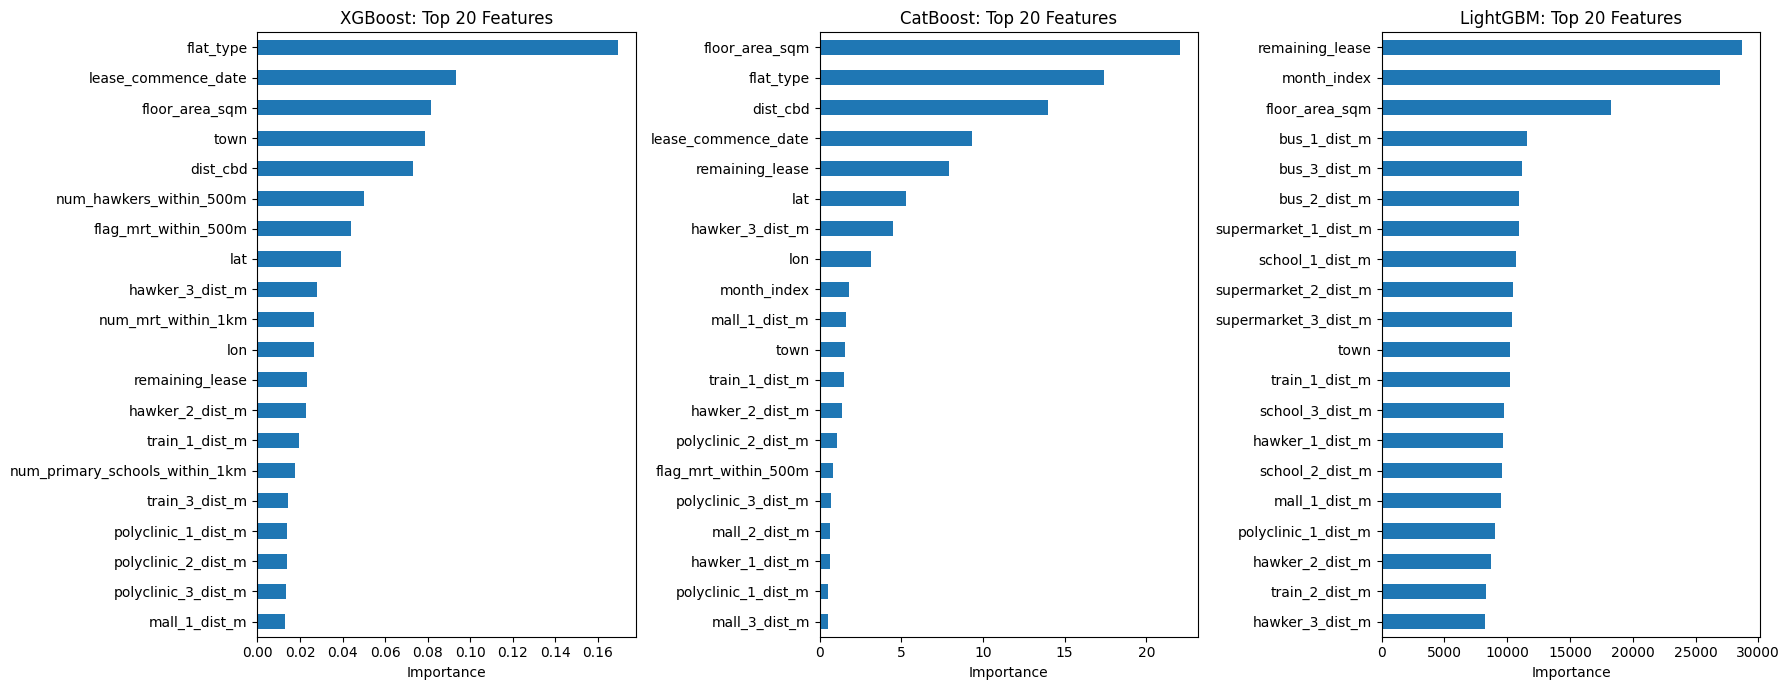

In [27]:
# Feature Importance (top 20)
feature_names_raw = X_train_raw.columns.tolist()
feature_names_lgb = X_train_lgb.columns.tolist()
xgb_imp = pd.Series(xgb_model.feature_importances_, index=feature_names_raw).sort_values(ascending=False)
cb_imp = pd.Series(cb_model.get_feature_importance(), index=feature_names_raw).sort_values(ascending=False)
lgb_imp = pd.Series(lgb_model.feature_importances_, index=feature_names_lgb).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, imp, title in zip(axes, 
                          [xgb_imp, cb_imp, lgb_imp],
                          ["XGBoost", "CatBoost", "LightGBM"]):
    imp.head(20).plot(kind="barh", ax=ax)
    ax.set_title(f"{title}: Top 20 Features")
    ax.invert_yaxis(); ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [28]:
# Final Comparison Tables
results_all = [
    res_global_median, res_strat_median,
    res_lr,
    res_rf,
    res_lgb_sym, res_lgb,
    res_xgb_sym, res_xgb,
    res_cb_sym, res_cb,
    res_ens_b,
    *([res_ens_c] if res_ens_c is not None else []),
    res_ens_opt
]

summary = pd.DataFrame(results_all).set_index("name")

print(f"\n=== Sorted by Asymmetric Loss ===")
print(summary.sort_values("Lin-Lin").to_string(float_format=lambda x: f"{x:,.2f}"))

print(f"\n=== Sorted by Symmetric Loss ===")
print(summary.sort_values("MAE_nominal").to_string(float_format=lambda x: f"{x:,.2f}"))


=== Sorted by Asymmetric Loss ===
                                        Lin-Lin  Coverage  MAE_nominal       MAE       RMSE  MAPE
name                                                                                             
Ensemble (boosting, equal weights)     5,856.91      0.76    35,871.58 18,181.84  25,102.72  5.73
Ensemble (optimised weights)           5,857.35      0.76    35,822.06 18,158.15  25,103.33  5.72
Ensemble (boosting+RF, equal weights)  5,909.30      0.72    33,669.18 17,063.15  23,792.47  5.36
CatBoost (Asymmetric)                  5,919.74      0.76    36,046.44 18,273.91  25,307.92  5.74
XGBoost (Asymmetric)                   5,922.66      0.76    36,397.62 18,446.01  25,394.83  5.82
LightGBM (Asymmetric)                  5,958.98      0.75    36,082.48 18,286.93  25,288.00  5.75
CatBoost (Symmetric)                   6,642.06      0.55    29,120.10 14,762.91  20,793.75  4.57
LightGBM (Symmetric)                   6,677.61      0.56    29,501.43 14,953.44  2

In [29]:
MODEL_KEY_MAP = {"LightGBM": "lgbm", "XGBoost": "xgb", "CatBoost": "cb"}

ci_offsets = {
    "ensemble": {                                            # always optimised weights
        "p025_real": float(np.percentile(y_test.values - opt_pred, 2.5)),
        "p975_real": float(np.percentile(y_test.values - opt_pred, 97.5)),
    },
    "ensemble_equal": {                                      # always equal weights
        "p025_real": float(np.percentile(y_test.values - equal_pred, 2.5)),
        "p975_real": float(np.percentile(y_test.values - equal_pred, 97.5)),
    },
}

# Per-model residuals
for model_name, pred in winners_pred.items():
    key = MODEL_KEY_MAP.get(model_name)
    if key:
        r = y_test.values - pred
        ci_offsets[key] = {"p025_real": float(np.percentile(r, 2.5)),
                           "p975_real": float(np.percentile(r, 97.5))}
        print(f"CI offsets stored for key {key}")

with open("../json_outputs/ci_offsets.json", "w") as f:
    json.dump(ci_offsets, f, indent=2)
print("Saved keys:", list(ci_offsets.keys()))

CI offsets stored for key lgbm
CI offsets stored for key xgb
CI offsets stored for key cb
Saved keys: ['ensemble', 'ensemble_equal', 'lgbm', 'xgb', 'cb']


In [34]:
# Save winner models + final ensemble weights
os.makedirs("../models", exist_ok=True)
winners_model["CatBoost"].save_model("../models/cb_model.cbm")
winners_model["XGBoost"].save_model("../models/xgb_model.ubj")
joblib.dump(winners_model["LightGBM"], "../models/lgb_model.joblib")
with zipfile.ZipFile("../models/lgb_model.zip", "w", zipfile.ZIP_DEFLATED, compresslevel=9) as zf:
    zf.write("../models/lgb_model.joblib", "lgb_model.joblib")
print(f"Original: {os.path.getsize('../models/lgb_model.joblib') / 1e6:.1f} MB")
print(f"Zipped: {os.path.getsize('../models/lgb_model.joblib.zip') / 1e6:.1f} MB")
print(f"Saved models: {list(winners_model.keys())}")
np.save("../models/ensemble_weights.npy", opt_weights)
print(f"Saved optimised weights: {opt_weights.round(3)} for {final_model_names}")
print(f"(Final/recommended model: {final_model_names}, weights: {final_weights.round(3)})")

Original: 28.7 MB
Zipped: 10.2 MB
Saved models: ['LightGBM', 'XGBoost', 'CatBoost']
Saved optimised weights: [0.26  0.157 0.583] for ['LightGBM', 'XGBoost', 'CatBoost']
(Final/recommended model: ['LightGBM', 'XGBoost', 'CatBoost'], weights: [0.333 0.333 0.333])
